<a href="https://colab.research.google.com/github/MonikSense/Traffic_Accident/blob/main/NE-MGCNN-Final3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(



Model Comparison:

                     Accuracy  Precision    Recall  F1-score   ROC-AUC
XGBoost               0.67500   0.433333  0.270833  0.333333  0.476376
Neural Network        0.63125   0.322581  0.208333  0.253165  0.469680
Random Forest         0.71875   0.800000  0.083333  0.150943  0.532180
Logistic Regression   0.71250   0.750000  0.062500  0.115385  0.542969


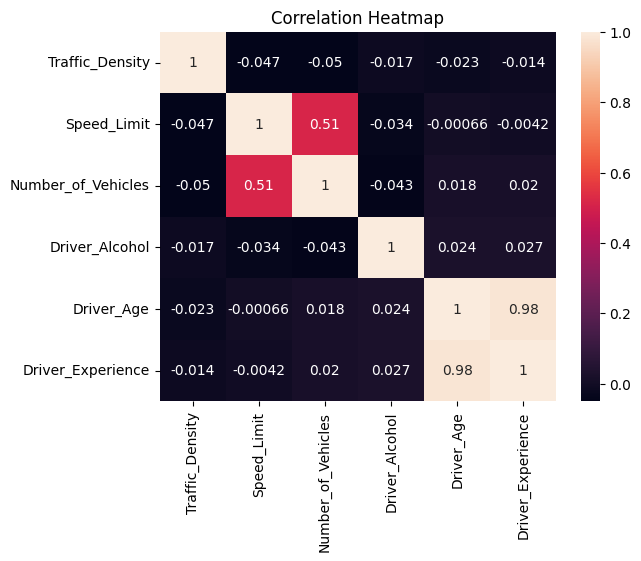

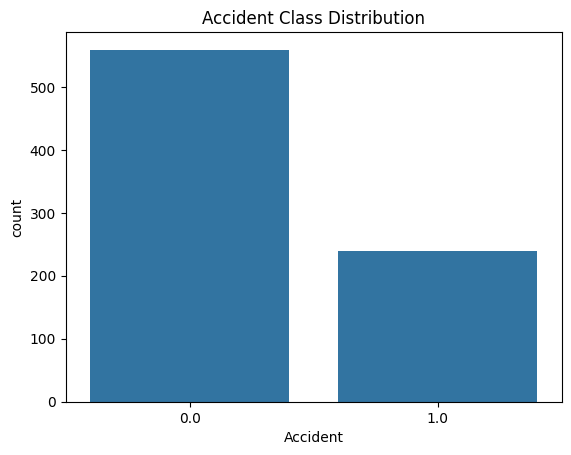

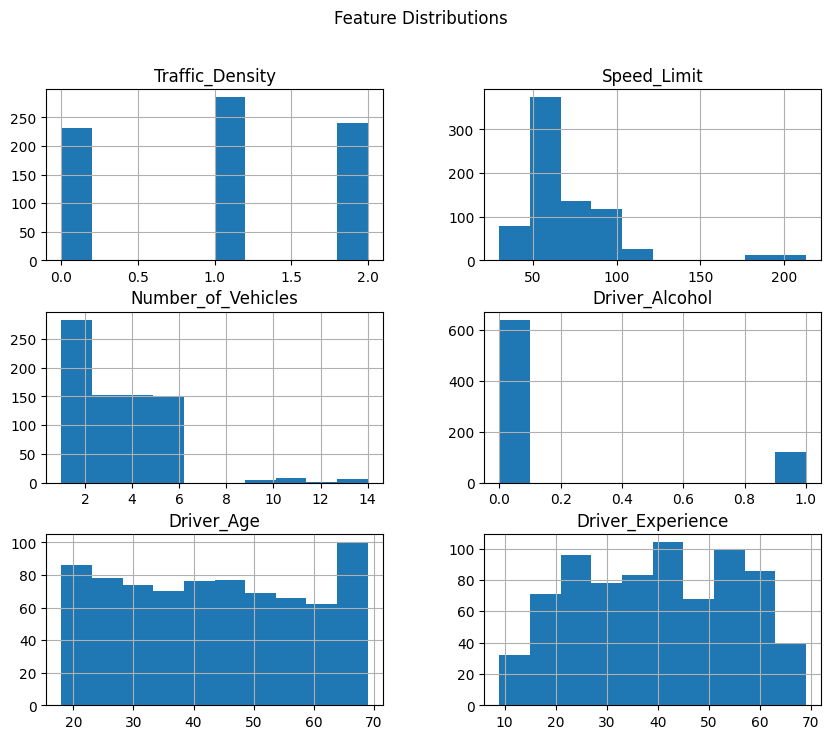

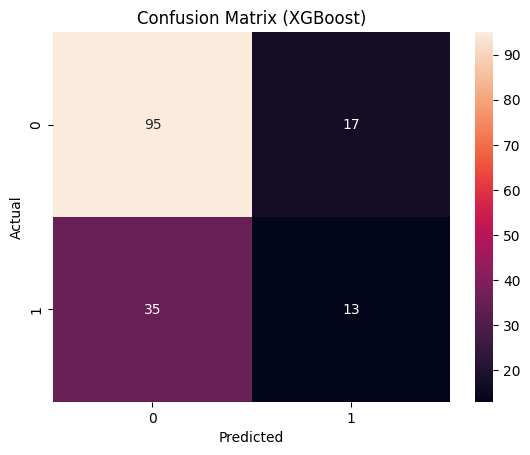

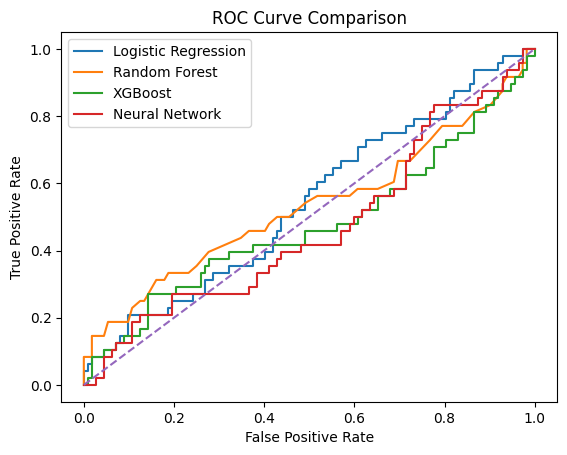

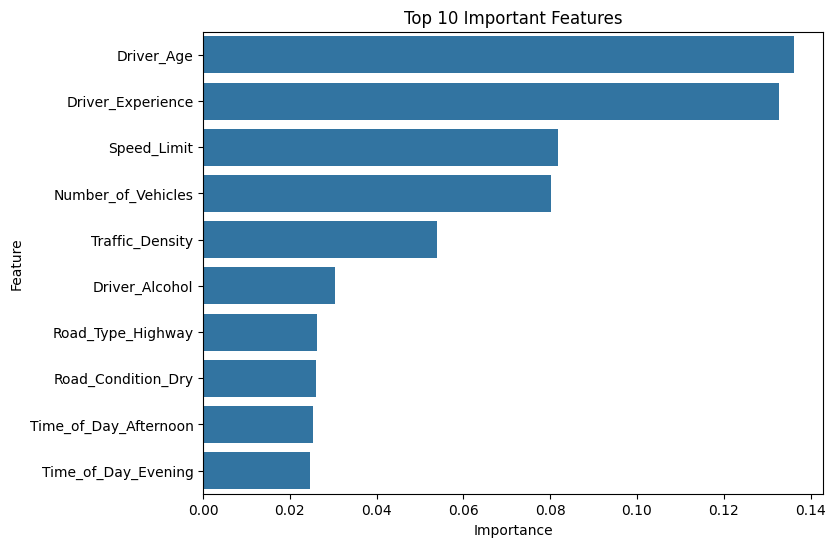


Hybrid Model Performance:
Accuracy: 0.7
Precision: 0.0
Recall: 0.0
F1-score: 0.0
ROC-AUC: 0.5212053571428572


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# =========================================
# 1. Import Libraries
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC


from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# =========================================
# 2. Load Dataset
# =========================================
df = pd.read_csv("https://raw.githubusercontent.com/MonikSense/Traffic_Accident/refs/heads/main/V1-dataset_traffic_accident_prediction1.csv")

target = "Accident"  # change if needed

# =========================================
# 3. Fix ERROR: Remove NaN from target
# =========================================
df = df.dropna(subset=[target])

# =========================================
# 4. Split Features & Target
# =========================================
X = df.drop(columns=[target])
y = df[target]

# =========================================
# 5. Identify Feature Types
# =========================================
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

# =========================================
# 6. Preprocessing Pipelines (IMPORTANT FIX)
# =========================================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# =========================================
# 7. Train-Test Split
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================
# 8. Models
# =========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=150, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300)
}

results = {}

# =========================================
# 9. Training & Evaluation
# =========================================
for name, model in models.items():

    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    results[name] = {
        "model": clf,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "y_pred": y_pred,
        "y_prob": y_prob
    }

# =========================================
# 10. Results Table
# =========================================
results_df = pd.DataFrame({
    k: [v["accuracy"], v["precision"], v["recall"], v["f1"], v["roc_auc"]]
    for k, v in results.items()
}, index=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]).T

print("\nModel Comparison:\n")
print(results_df.sort_values(by="F1-score", ascending=False))


plt.figure()
sns.heatmap(df[numerical_cols].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

plt.figure()
sns.countplot(x=target, data=df)
plt.title("Accident Class Distribution")
plt.show()

df[numerical_cols].hist(figsize=(10,8))
plt.suptitle("Feature Distributions")
plt.show()

best_model_name = results_df["F1-score"].idxmax()
best_model = results[best_model_name]["model"]

cm = confusion_matrix(y_test, results[best_model_name]["y_pred"])

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title(f"Confusion Matrix ({best_model_name})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure()

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

rf_model = results["Random Forest"]["model"]

# Get feature names
ohe = rf_model.named_steps["preprocessor"].named_transformers_["cat"]["onehot"]
encoded_cat_features = ohe.get_feature_names_out(categorical_cols)

all_features = numerical_cols + list(encoded_cat_features)

importances = rf_model.named_steps["model"].feature_importances_

feat_imp = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp.head(10))
plt.title("Top 10 Important Features")
plt.show()


# Base learners
base_models = [
    ("rf", RandomForestClassifier(n_estimators=100)),
    ("xgb", XGBClassifier(eval_metric='logloss')),
    ("dt", DecisionTreeClassifier()),
    ("svm", SVC(probability=True))
]

# Meta learner
meta_model = LogisticRegression()

# Stacking model
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5
)

# Pipeline
hybrid_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", stacking_model)
])

# Train
hybrid_pipeline.fit(X_train, y_train)

# Predict
y_pred_hybrid = hybrid_pipeline.predict(X_test)
y_prob_hybrid = hybrid_pipeline.predict_proba(X_test)[:, 1]

# Metrics
print("\nHybrid Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_hybrid))
print("Precision:", precision_score(y_test, y_pred_hybrid))
print("Recall:", recall_score(y_test, y_pred_hybrid))
print("F1-score:", f1_score(y_test, y_pred_hybrid))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_hybrid))